## Required packages

In [2]:
# Uncomment and execute if any of the following packages are not installed:
# %pip install numpy
# %pip install scipy
# %pip install matplotlib matplotlib-scalebar
# %pip install ipywidgets ipympl

## Import python libraries/modules

In [1]:
import numpy as np
import scipy.ndimage
from scipy.ndimage import rotate
from scipy.special import fresnel
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.cm as mcm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.transforms as mtransforms
from ipywidgets import interact
## For regular static images
%matplotlib inline 
## Interactively zoom into a specific area of a plot, need module ipympl
#%matplotlib widget

## Import source data

In [3]:
## Full-field images
imf_sw_co = np.loadtxt('Fig3_FigS5_PanelA_array.csv', delimiter=',')
imf_loop_co = np.loadtxt('Fig3_FigS5_PanelB_array.csv', delimiter=',')
imf_sw_fmo = np.loadtxt('Fig3_FigS5_PanelC_array.csv', delimiter=',')

In [4]:
## Truncate imgaes
imt_sw_co = imf_sw_co[:,0:630]
imt_loop_co = imf_loop_co[0:295,:]
imt_sw_fmo = imf_sw_fmo[:,0:585]

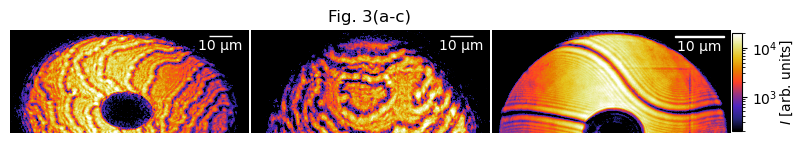

In [5]:
fig, ax= plt.subplots(1,3, figsize=(8,3))
ax[0].imshow(rotate(abs(imt_sw_co), angle=270, reshape=True), cmap='CMRmap', norm=colors.LogNorm(vmin=200, vmax=2e4),aspect=1/1.4585) ## 1/sin(43.5 deg)
ax[1].imshow(rotate(abs(imt_loop_co), angle=0, reshape=True), cmap='CMRmap', norm=colors.LogNorm(vmin=200, vmax=1e4),aspect=1.4585) ## 1/sin(43.5 deg)
p3 = ax[2].imshow(rotate(abs(imt_sw_fmo), angle=270, reshape=True), cmap='CMRmap', norm=colors.LogNorm(vmin=200, vmax=2e4),aspect=1/1.137) ## 1/sin(61.6 deg)
cbar1=fig.colorbar(p3, ax=ax[2], cax=ax[2].inset_axes([1.01, 0.02,0.04, 0.95]))
cbar1.set_label(r'$I$ [arb. units]', labelpad=1, rotation=90, fontsize=10)
cbar1.set_ticks([1000, 10000])
fontprops = fm.FontProperties(size=10)
scalebar = AnchoredSizeBar(ax[0].transData, 
                           95.24, '10 µm', 'upper right', 
                           pad=0.3, 
                           color='white', 
                           frameon=False, 
                           size_vertical=5, sep=2, fontproperties=fontprops) ##1 pixel=0.0755 micron updated to 0.105 used for T vs Shift calculations

ax[0].add_artist(scalebar)
scalebar1 = AnchoredSizeBar(ax[1].transData, 
                           95.24, '10 µm', 'upper right', 
                           pad=0.3, 
                           color='white', 
                           frameon=False, 
                           size_vertical=2, sep=2, fontproperties=fontprops) ##1 pixel=0.105 micron

ax[1].add_artist(scalebar1)
scalebar_fmo = AnchoredSizeBar(ax[2].transData, 
                           250, '10 µm', 'upper right', 
                           pad=0.3, 
                           color='white', 
                           frameon=False, 
                           size_vertical=5, sep=2, fontproperties=fontprops) ##1 pixel=0.04 micron
ax[2].add_artist(scalebar_fmo)
for jj in range(3):
    ax[jj].set_axis_off()
ax[1].set_title('Fig. 3(a-c)')
fig.subplots_adjust(left=0.0, wspace=0.01, hspace=0.001)
# plt.savefig('Fig3a-c.png', dpi=300, format='png', metadata=None,
#         bbox_inches='tight', pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None)
plt.show()

## Simulate Fresnel intensity produced by two staright domain walls

In [6]:
def simulate_double_wall(wave=1.45e-9, lx=30e-6, ly=30e-6, width=300e-9, separation=10e-6, z_foc = 2.7e-3, z_obs = 304e-3):
    # Experimental Parameters
    wavelength = wave
    z1 = z_foc
    z2 = z_obs
    zeff = (z1 * z2) / (z1 + z2)
    w_eff = width
    wall_sep = separation
    
    # Simulation Window (x is across the walls, y is along the walls)
    x_dim = np.linspace(-lx, lx, 30000)
    y_dim = np.linspace(-ly, ly, 500)
    X, Y = np.meshgrid(x_dim, y_dim)   
 
    # Propagation scaling
    k = 2 * np.pi / wavelength
    alpha = k / (2 * zeff)
    
    # Sample grid (surface)
    x_s = np.linspace(-60e-6, 60e-6, 60000)
    dx = x_s[1] - x_s[0]
    
    def get_single_wall_profile(reverse=False):
        phi = np.zeros_like(x_s)
        if not reverse: # 0 to 180
            phi[x_s > w_eff/2] = np.pi
            mask = (x_s >= -w_eff/2) & (x_s <= w_eff/2)
            phi[mask] = np.pi * (x_s[mask] + w_eff/2) / w_eff
        else: # 180 to 360
            phi[x_s < -w_eff/2] = np.pi
            mask = (x_s >= -w_eff/2) & (x_s <= w_eff/2)
            phi[mask] = np.pi * (1 - (x_s[mask] + w_eff/2) / w_eff)
           
        # Complex field at source
        U0 = np.exp(1j * phi)
        
        # Observation plane
        x_obs = np.linspace(-30e-6, 30e-6, 5*1200)
        # Fresnel propagation (Direct integration)
        profile = np.zeros_like(x_obs)
        for i, xo in enumerate(x_obs):
            sub = (x_s > xo - 30e-6) & (x_s < xo + 30e-6)
            field = np.sum(U0[sub] * np.exp(1j * alpha * (xo - x_s[sub])**2)) * dx
            profile[i] = np.abs(field)**2
        return x_obs, profile / (wavelength * zeff)  # Normalized by the background intensity (far from the wall)

    # Wall 1: 0 -> 180
    x_rel, prof1 = get_single_wall_profile(reverse=True)
    # Wall 2: 180 -> 0
    _, prof2 = get_single_wall_profile(reverse=True)
    
    # Reconstruct 2D intensity by shifting profiles along y
    intensity_2d = np.zeros((len(y_dim), len(x_dim)))
    
    for i, y_val in enumerate(y_dim):       
        line1 = np.interp(x_dim - wall_sep, x_rel, prof1, left=1, right=1)
        line2 = np.interp(x_dim + wall_sep, x_rel, prof2, left=1, right=1)        
        # The background is normalized to 1. 
        intensity_2d[i, :] = line1 * line2

    extent_sw=[x_dim[0]*1e6, x_dim[-1]*1e6, y_dim[0]*1e6, y_dim[-1]*1e6]
    return intensity_2d, extent_sw

In [7]:
sw_co, extent_sw_co= simulate_double_wall(wave=1.45e-9, lx=45e-6, ly=30e-6, width=300e-9, separation=10e-6, z_foc = 2.7e-3, z_obs = 304e-3) 
sw_fmo, extent_sw_fmo= simulate_double_wall(wave=1.75e-9, lx=25e-6, ly=16.667e-6, width=1e-9, separation=10e-6, z_foc = 1.43e-3, z_obs = 304e-3)

## Simulate Fresnel intensity produced by loop domain walls

In [8]:
def simulate_concentric_loops(wave=1.45e-9, lattice=60e-6, reso =2*1024, inner=10e-6, outer=25e-6, width=300e-9, z_foc = 2.7e-3, z_obs = 304e-3):
    # Parameters
    wavelength = wave
    z1 = z_foc  ## X-ray focus position relative to sample
    z2 = z_obs  ## Detector position relative to sample
    zeff = (z1 * z2) / (z1 + z2)
    w_DW = width
    
    # Simulation Window
    L = lattice #60e-6
    N = reso #2*1024
    du = L / N
    u = np.linspace(-L/2, L/2, N)
    v = np.linspace(-L/2, L/2, N)
    U, V = np.meshgrid(u, v)
    
    # Project to surface coordinates
    X = U 
    Y = V 
    R_surf = np.sqrt(X**2 + Y**2)
    
    # Ring Domain Radii
    R1 = inner #10e-6 # Inner
    R2 = outer #25e-6 # Outer
    
    # Phase profile: 0 (outside) -> 180 (ring) -> 0 (center)

    phi = np.zeros_like(R_surf)
        
    # Inner Wall (0 to 180)
    mask_in = (R_surf >= R1 - w_DW/2) & (R_surf <= R1 + w_DW/2)
    phi[mask_in] = np.pi * (R_surf[mask_in] - (R1 - w_DW/2)) / w_DW
        
    # Ring (180 deg)
    mask_ring = (R_surf > R1 + w_DW/2) & (R_surf < R2 - w_DW/2)
    phi[mask_ring] = np.pi
        
    # Outer Wall (180 to 360)
    mask_out = (R_surf >= R2 - w_DW/2) & (R_surf <= R2 + w_DW/2)
    phi[mask_out] = np.pi + np.pi * (R_surf[mask_out] - (R2 - w_DW/2)) / w_DW
        
    # Outer Matrix (360 / 2pi)
    phi[R_surf > R2 + w_DW/2] = 2 * np.pi
   
    # Complex field
    U0 = np.exp(1j * phi)
    
    # Fresnel Propagation (Transfer Function)
    f_vec = np.fft.fftfreq(N, d=du)
    FX, FY = np.meshgrid(f_vec, f_vec)
    H = np.exp(-1j * np.pi * wavelength * zeff * (FX**2 + FY**2))
    
    U_prop = np.fft.ifft2(np.fft.fft2(U0) * H)
    intensity = np.abs(U_prop)**2
    extent_loop=[-L/2*1e6, L/2*1e6, -L/2*1e6, L/2*1e6]
    return intensity, extent_loop

In [9]:
loop_co, extent_loop= simulate_concentric_loops(wave=1.45e-9, lattice=90e-6, reso= 2*1024, inner=10e-6, outer=23e-6, width=300e-9, z_foc = 2.7e-3, z_obs = 304e-3)

### Simulated Fresnel intensity maps for Ni$_2$CoTeO$_6$ and Fe$_2$Mo$_3$O$_8$ [$Fig. 3(d-f)$]

In [10]:
plt.rcParams.update({"text.usetex": True, "text.latex.preamble": r"\usepackage{amsmath}"})

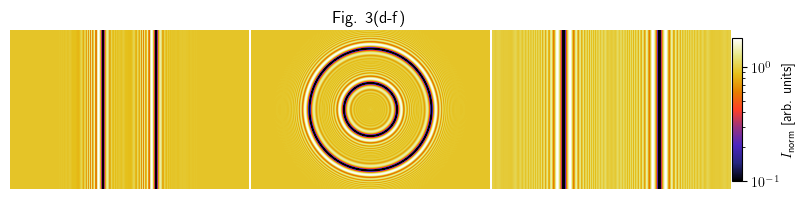

In [11]:
fig, ax= plt.subplots(1,3, figsize=(8,3))
ax[0].imshow(sw_co, extent=extent_sw_co, cmap='CMRmap', norm = colors.LogNorm(vmin=0.1, vmax=2))
ax[1].imshow(loop_co, extent=extent_loop, cmap='CMRmap', norm = colors.LogNorm(vmin=0.1, vmax=2))
q3=ax[2].imshow(sw_fmo, extent=extent_sw_fmo, cmap='CMRmap', norm = colors.LogNorm(vmin=0.1, vmax=1.8))
cbar2=fig.colorbar(q3, ax=ax[2], cax=ax[2].inset_axes([1.01, 0.05,0.04, 0.9]))
cbar2.set_label(r'$I_{\text{norm}}$ [arb. units]', labelpad=1, rotation=90, fontsize=10)
for ii in range(3):
    ax[ii].set_axis_off()
ax[1].set_ylim(-30, 30)
ax[1].set_title('Fig. 3(d-f)')
fig.subplots_adjust(left=0.0, wspace=0.01, hspace=0.001)
# plt.savefig('Fig3d-f.png', dpi=300, format='png', metadata=None,
#         bbox_inches='tight', pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None)

### Full-field images AFM textures in Ni$_2$CoTeO$_6$ and Fe$_2$Mo$_3$O$_8$ [$Fig. S5(a-c)$]

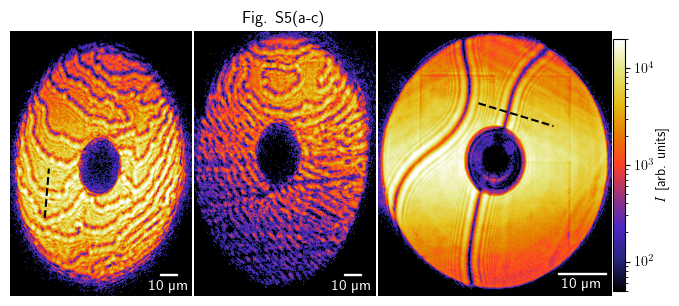

In [12]:
# Width ratios (Inverse of vertical aspect factors due to beam footprint)
widths = [1 / 1.4585, 1 / 1.4585, 1 / 1.137]

# Create the grid 
fig, ax = plt.subplots(
    1, 3, 
    figsize=(sum(widths) * 3, 4), # Dynamically scales the canvas width to match the images
    gridspec_kw={'width_ratios': widths}
)

# Plotting the data exactly as required with vertical aspect factors
ax[0].imshow(abs(imf_sw_co), cmap='CMRmap', norm=colors.LogNorm(vmin=100, vmax=2e4), aspect=1.4585)
ax[1].imshow(abs(imf_loop_co), cmap='CMRmap', norm=colors.LogNorm(vmin=50, vmax=2e4), aspect=1.4585)
p3 = ax[2].imshow(abs(imf_sw_fmo), cmap='CMRmap', norm=colors.LogNorm(vmin=50, vmax=2e4), aspect=1.137)
cbar=fig.colorbar(p3, ax=ax[2], cax=ax[2].inset_axes([1.01, 0.02,0.05, 0.95]))
cbar.set_label(r'$I$ [arb. units]', labelpad=1, rotation=90, fontsize=10)
fontprops = fm.FontProperties(size=11)
scalebar = AnchoredSizeBar(ax[0].transData, 
                           95.24, '10 µm', 'lower right', 
                           pad=0.1, 
                           color='white', 
                           frameon=False, 
                           size_vertical=4, sep=3, fontproperties=fontprops) ## 1 pixel=0.105 micron on sample Ni2CoTeO6

ax[0].add_artist(scalebar)
scalebar1 = AnchoredSizeBar(ax[1].transData, 
                           95.24, '10 µm', 'lower right', 
                           pad=0.1, 
                           color='white', 
                           frameon=False, 
                           size_vertical=4, sep=3, fontproperties=fontprops) ## 1 pixel=0.105 micron on sample Ni2CoTeO6
ax[1].add_artist(scalebar1)
scalebar_fmo = AnchoredSizeBar(ax[2].transData, 
                           250, '10 µm', 'lower right', 
                           pad=0.2, 
                           color='white', 
                           frameon=False, 
                           size_vertical=4, sep=3, fontproperties=fontprops) ## 1 pixel=0.04 micron on sample Fe2Mo3O8
ax[2].add_artist(scalebar_fmo)
ax[1].set_title('Fig. S5(a-c)')
#####################################################################################################
line1co_x = np.array([259, 446])
line1co_y = np.array([218, 218])
line2co_x = np.array([457, 640])
line2co_y = np.array([290, 290])
tr1co = mtransforms.Affine2D().rotate_deg_around(500, 500, -83+0)
tr2co = mtransforms.Affine2D().rotate_deg_around(500, 500, -73+0)
rotated_transform1co = tr1co + ax[0].transData
rotated_transform2co = tr2co + ax[0].transData
ax[0].plot(line1co_x, line1co_y, '--', color='black', linewidth=1.5, alpha=1, transform=rotated_transform1co)
########################################################################################################
line1fe_x = np.array([450, 850])
line1fe_y = np.array([358, 358])
line2fe_x = np.array([120, 650])
line2fe_y = np.array([909, 909])
tr1fe = mtransforms.Affine2D().rotate_deg_around(600, 600, 15+0)
tr2fe = mtransforms.Affine2D().rotate_deg_around(600, 600, 55+0)
rotated_transform1fe = tr1fe + ax[2].transData
rotated_transform2fe = tr2fe + ax[2].transData
ax[2].plot(line1fe_x, line1fe_y, '--', color='black', linewidth=1.5, alpha=1, transform=rotated_transform1fe)
#######################################################################################################
# Remove axes 
for a in ax:
    a.axis('off')

fig.subplots_adjust(left=0.01,  wspace=0.01)
plt.show()
# plt.savefig('Fig3Sa-c_logCMRmap.png', dpi=300, format='png', metadata=None,
#         bbox_inches='tight', pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None)

### Zoomed-in simulated Fresnel maps for Ni$_2$CoTeO$_6$ and Fe$_2$Mo$_3$O$_8$ [$Fig. S5(d-f)$]

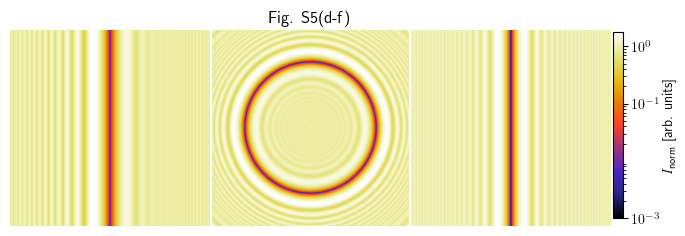

In [13]:
fig, ax= plt.subplots(1,3, figsize=(6.75,6.75/2.65))
swco = sw_co 
loopco = loop_co 
swfmo = sw_fmo 
ax[0].imshow(swco, extent=extent_sw_co, cmap='CMRmap', aspect='auto', norm = colors.LogNorm(vmin=0.001, vmax=2))
ax[1].imshow(loopco, extent=extent_loop, cmap='CMRmap', aspect='equal', norm = colors.LogNorm(vmin=0.001, vmax=2))
pic3 = ax[2].imshow(swfmo, extent=extent_sw_fmo, cmap='CMRmap', aspect='auto', norm = colors.LogNorm(vmin=0.001, vmax=1.8))
cbar=fig.colorbar(pic3, ax=ax[2], ticks=[0.001, 0.1, 1], cax=ax[2].inset_axes([1.01, 0.04,0.05, 0.95]))
cbar.set_label(r'$I_{\text{norm}}$ [arb. units]', labelpad=1, rotation=90, fontsize=10)
ax[0].set_xlim(-20,0)
ax[1].set_xlim(-15,15)
ax[1].set_ylim(-15,15)
ax[2].set_xlim(-20,0)
ax[1].set_title('Fig. S5(d-f)')
for ii in range(3):
    ax[ii].set_axis_off()
fig.subplots_adjust(left=0.01, wspace=0.002)
plt.show()
# plt.savefig('Fig3Sd-f_log_CMRmap.png', dpi=300, format='png', metadata=None,
#         bbox_inches='tight', pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None)

### Line profiles across the above simulated walls [$Fig. S5(g-i)$]

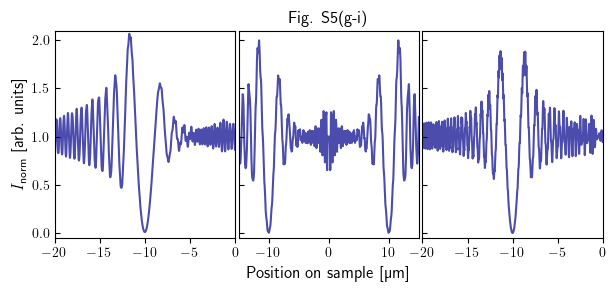

In [14]:
fig, ax= plt.subplots(1,3, figsize=(6.75+0.1,6.75/2.65+0.5))
slice1d_swco = swco[250,:]
slice1d_loopco = loopco[1024,:]
slice1d_loopco[1020:1028]=1
slice1d_swfmo = swfmo[250,:]
x_swco = np.linspace(-45, 45, 30000)
x_loop = np.linspace(-45, 45, 2048)
x_swfmo = np.linspace(-25, 25, 30000)
ax[0].plot(x_swco, slice1d_swco, color='darkblue', lw=1.5, alpha=0.7)
ax[1].plot(x_loop, slice1d_loopco, color='darkblue', lw=1.5, alpha=0.7)
ax[2].plot(x_swfmo, slice1d_swfmo, color='darkblue', lw=1.5, alpha=0.7)
ax[0].set_xlim(-20,0)
ax[1].set_xlim(-15,15)
ax[2].set_xlim(-20,0)
ax[0].set_ylim(-0.05,2.1)
ax[1].set_ylim(-0.05,2.1)
ax[2].set_ylim(-0.05,2.1)
ax[0].set_ylabel(r'$I_{\text{norm}}$ [arb. units]', fontsize=12)
ax[0].tick_params(axis='y', direction='in')
ax[1].tick_params(axis='y', direction='in')
ax[2].tick_params(axis='y', direction='in')
ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[1].set_xlabel('Position on sample [µm]', fontsize=12)
ax[1].set_title('Fig. S5(g-i)')
fig.subplots_adjust(left=0.1,  bottom=0.2, wspace=0.02)
# plt.savefig('Fig3Sg-i_theta=0_zoomed.png', dpi=300, format='png', metadata=None,
#         bbox_inches='tight', pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None)

## Simulate intensity for different phase profile and wall widths [$Fig. S3(a-f)$]

In [15]:
def FI_dw_profiles(wave=1.45e-9, phase=180, width=300e-9, z_foc=2.7e-3, z_obs=304e-3, x_obs=15e-6, reso=1200, dxs=10e-9):
    # Parameters
    wavelength = wave
    z1, z2 = z_foc, z_obs
    z_eff = (z_foc * z_obs) / (z_foc + z_obs)
    w_DW = width
    k = 2 * np.pi / wavelength
    
    # Grid setup
    xs_max = 60e-6
    xs = np.arange(-xs_max, xs_max, dxs)
    x_obs_eff = np.linspace(-x_obs, x_obs, reso)
    x_det = x_obs_eff * 1e6
    
    # Define Profiles
    delta_phi = np.radians(phase)
    prefactor = np.sqrt(2 / (wavelength * z_eff))
    u = x_obs_eff * prefactor    
    S, C = fresnel(u)    
    # Normalized field components
    # Left side (u < 0) has phase 0
    # Right side (u > 0) has phase delta_phi
    # The integration of the Fresnel kernel from -inf to u and u to inf:
    E_left = 0.5 * ( (0.5 - C) + 1j * (0.5 - S) ) * (1 - 1j)
    E_right = np.exp(1j * delta_phi) * 0.5 * ( (0.5 + C) + 1j * (0.5 + S) ) * (1 - 1j)    
    total_field = E_left + E_right
    I_s = np.abs(total_field)**2

    
    # 0. Ideal Step 
    phi_step = np.zeros_like(xs)
    phi_step[xs == 0] = 0
    phi_step[xs > 0] = delta_phi
    
    # 1. Linear
    phi_lin = np.zeros_like(xs)
    mask_ramp = (xs >= -w_DW/2) & (xs <= w_DW/2)
    phi_lin[mask_ramp] = delta_phi * (xs[mask_ramp] + w_DW/2) / w_DW
    phi_lin[xs > w_DW/2] = delta_phi
    
    # 4. Phenomenological tanh phase profile
    w = w_DW/2.197  ## w phenomenological width leading to physical width w_DW
    phi_tanh = (delta_phi / 2) * (1 + np.tanh(xs / w))

    Phase = [phi_step, phi_lin, phi_tanh]
    
    def get_intensity(phi_grid):
        U0 = np.exp(1j * phi_grid)
        diff_sq = (x_obs_eff[:, np.newaxis] - xs[np.newaxis, :])**2
        kernel = np.exp(1j * k / (2 * z_eff) * diff_sq)
        field = np.sum(U0 * kernel, axis=1) * dxs
        return np.abs(field)**2 / (wavelength * z_eff)

    # Calculate 1d intensity profiles
    I_step = I_s
    I_lin = get_intensity(phi_lin)
    I_tanh = get_intensity(phi_tanh)
    FI = [I_step, I_lin, I_tanh]
    
    # Calculate 2d intensity map
    map_step = np.tile(I_step, (300, 1))
    map_lin = np.tile(I_lin, (300, 1))
    map_tanh = np.tile(I_tanh, (300, 1))
    Fmap = [map_step, map_lin, map_tanh]
    
    # Indices for peaks around center
    def get_parameters(intensity):
        center_idx = len(x_det)//2
        I = intensity
        lp = np.max(I[:center_idx])
        rp = np.max(I[center_idx:])
        Asy = np.abs((lp - rp) / (lp + rp))*100
        return Asy

    # Calculate peak parameters
    P_step = get_parameters(I_step)
    P_lin = get_parameters(I_lin)
    P_tanh = get_parameters(I_tanh)
    A = [P_step, P_lin, P_tanh]
  
    return xs, x_det, Phase, FI, Fmap, A

### Simulate asymmetry ratio $A$ versus wall width w$_{DW}$ for Ni$_2$CoTeO$_6$

In [16]:
w_DW = [1, 10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Asy = []
for w in w_DW:
    out = FI_dw_profiles(wave=1.45e-9, phase=180, width=w*1e-9, z_foc=2.7e-3, z_obs=304e-3, x_obs=9e-6, reso=300, dxs=1e-9)
    Asy.append(out[5])

In [17]:
Asy_arr = np.array(Asy)
A1, A2, A3 = Asy_arr.T

In [18]:
xs, x_det, Phase, FI, Fmap, A= FI_dw_profiles(wave=1.45e-9, phase=180, width=300e-9, z_foc=2.7e-3, z_obs=304e-3, x_obs=9e-6, reso=300, dxs=1e-9)

### Generate Fig. S3(a-f)

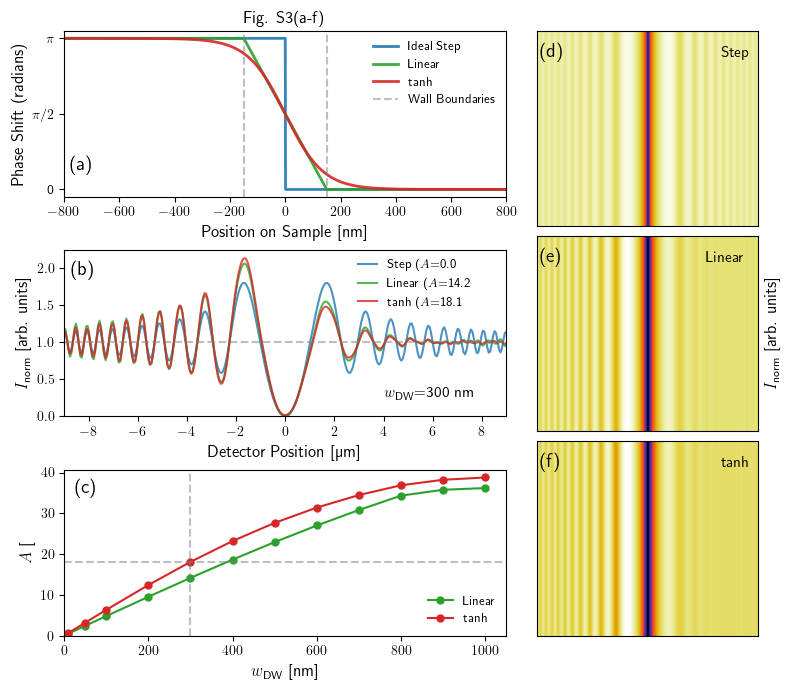

In [19]:
# 1. Initialize the figure
fig = plt.figure(figsize=(8, 7))

# 1. Create the top-level layout (1 row, 2 columns)
outer_gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[2, 1])

# 2. Split Column 1 independently (3 rows, default or custom spacing)
gs_col1 = outer_gs[0, 0].subgridspec(nrows=3, ncols=1, hspace=0.32)
ax1_top = fig.add_subplot(gs_col1[0, 0])
ax1_bottom = fig.add_subplot(gs_col1[1, 0])
ax1_middle = fig.add_subplot(gs_col1[2, 0])

# 3. Split Column 2 independently (3 rows)
gs_col2 = outer_gs[0, 1].subgridspec(nrows=3, ncols=1, hspace=0.05)

ax2_1 = fig.add_subplot(gs_col2[0, 0])
ax2_2 = fig.add_subplot(gs_col2[1, 0])
ax2_3 = fig.add_subplot(gs_col2[2, 0])

# Turn off ticks/labels for Column 2 
for ax in [ax2_1, ax2_2, ax2_3]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.yaxis.set_label_position('right')

# 5. Plotting phase profiles
ax1_top.plot(-xs*1e9, Phase[0], color='tab:blue', label='Ideal Step',  lw=2, alpha=0.9, linestyle='-')
ax1_top.plot(-xs*1e9, Phase[1], color='tab:green', label='Linear',  lw=2, alpha=0.9, linestyle='-')
ax1_top.plot(-xs*1e9, Phase[2], color='tab:red', label='tanh',  lw=2, alpha=0.9, linestyle='-')
ax1_top.set_xlim(-800, 800)
ax1_top.axvline(-300/2, color='gray', linestyle='--', alpha=0.5, label='Wall Boundaries')
ax1_top.axvline(300/2, color='gray', linestyle='--', alpha=0.5)
ax1_top.set_xlabel('Position on Sample [nm]', fontsize=12)
ax1_top.set_ylabel('Phase Shift (radians)', fontsize=12)
ax1_top.set_yticks([0, np.pi/2, np.pi], labels=['0', r'$\pi/2$', r'$\pi$'])
ax1_top.legend(frameon=False, fontsize=9)
ax1_top.set_title('Fig. S3(a-f)')
#ax1_top.grid(True, alpha=0.3)

# 5. Plotting 1d intensity profiles
ax1_bottom.plot(-x_det, FI[0], color='tab:blue', label=f'Step ($A$={A[0]:0.1f}%)', lw=1.5, alpha=0.8, linestyle='-')
ax1_bottom.plot(-x_det, FI[1], color='tab:green', label=f'Linear ($A$={A[1]:0.1f}%)', lw=1.5, alpha=0.8, linestyle='-')
ax1_bottom.plot(-x_det, FI[2], color='tab:red', label=f'tanh ($A$={A[2]:0.1f}%)', lw=1.5, alpha=0.8, linestyle='-')
ax1_bottom.set_xlim(-9,9)
ax1_bottom.set_ylim(0,)
ax1_bottom.axhline(1, color='gray', linestyle='--', alpha=0.5)
ax1_bottom.set_xlabel('Detector Position [µm]', fontsize=12)
ax1_bottom.set_ylabel(r'$I_{\text{norm}}$ [arb. units]', fontsize=12)
ax1_bottom.legend(frameon=False, bbox_to_anchor=(0.64, .58), columnspacing=0, handlelength=1.5, fontsize=9)

ax1_middle.plot(w_DW, A2, '-o', markersize=5, color='tab:green', label='Linear', lw=1.5,)
ax1_middle.plot(w_DW , A3, '-o', markersize=5, color='tab:red', label='tanh', lw=1.5,)
ax1_middle.set_ylabel(r'$A$ [%]', fontsize=12)
ax1_middle.set_xlabel(r'$w_{\text{DW}}$ [nm]', fontsize=12)
ax1_middle.axhline(18, color='gray', linestyle='--', alpha=0.5)
ax1_middle.axvline(300, color='gray', linestyle='--', alpha=0.5)
ax1_middle.set_xlim(0,)
ax1_middle.set_ylim(0,)
ax1_middle.legend(frameon=False, loc='lower right', fontsize=9)
ax1_middle.text(26, 35, '(c)', color='black', fontsize=14)

# First column labeling
ax1_top.text(-780, 0.4, '(a)', color='black', fontsize=14)
ax1_bottom.text(-8.7, 1.9, '(b)', color='black', fontsize=14)
ax1_bottom.text(4, 0.25, r'$w_{\text{DW}}$=300 nm', fontsize=11)

# 5. Plotting 2d intensity maps
ax2_1.imshow(np.flip(Fmap[0]), extent=[x_det[0], x_det[-1], -150, 150], cmap='CMRmap', aspect='auto', norm = colors.LogNorm(vmax=2.1))
ax2_2.imshow(np.flip(Fmap[1]), extent=[x_det[0], x_det[-1], -150, 150], cmap='CMRmap', aspect='auto', norm = colors.LogNorm(vmax=2.1))
ax2_3.imshow(np.flip(Fmap[2]), extent=[x_det[0], x_det[-1], -150, 150], cmap='CMRmap', aspect='auto', norm = colors.LogNorm(vmax=2.1))
#ax2_1.set_ylabel(r'$I_{\text{norm}}$ [arb. units]', fontsize=12)
ax2_2.set_ylabel(r'$I_{\text{norm}}$ [arb. units]', fontsize=12)
#ax2_3.set_ylabel(r'$I_{\text{norm}}$ [arb. units]', fontsize=12)


# Second column labeling
labels = ['(d)','(e)','(f)']
model = ['Step', 'Linear', 'tanh']
for i, ax in enumerate([ax2_1, ax2_2, ax2_3], start=0):
    ax.text(-8.7, 110, labels[i], color='black', fontsize=14)
ax2_1.text(6, 110, model[0], color='black', fontsize=11)
ax2_2.text(4.8, 110, model[1], color='black', fontsize=11)
ax2_3.text(6, 110, model[2], color='black', fontsize=11)
# Add titles and clean up overlapping layout
fig.tight_layout()
plt.show()
fig.subplots_adjust(left=0.1, wspace=0.07, hspace=0.1)
# plt.savefig('FigS3.png', dpi=300, format='png', metadata=None,
#         bbox_inches='tight', pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None)

## Experimental slices across domain walls in Ni$_2$CoTeO$_6$ and Fe$_2$Mo$_3$O$_8$

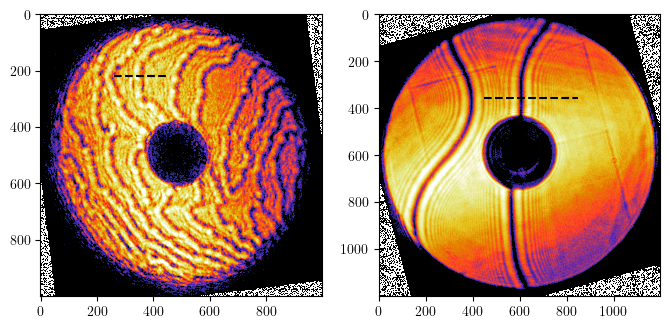

In [20]:
## Rotate the images so that wall profiles to be investigated become parallel to the horizonal axis 
fig, ax= plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(rotate(abs(imf_sw_co), angle=-83, reshape=False), cmap='CMRmap', norm=colors.LogNorm(vmin=200, vmax=2e4)) 
ax[0].plot([259, 446,], [218, 218,], '--', color='black', linewidth=1.5, alpha=1)
ax[1].imshow(rotate(abs(imf_sw_fmo), angle=15, reshape=False), cmap='CMRmap',norm=colors.LogNorm(vmin=200, vmax=2e4))
ax[1].plot([450, 850,], [358, 358,], '--', color='black', linewidth=1.5, alpha=1)

## **Compare experimental and simulated line profiles of domain walls [$Fig. S6(a-b)$]**

### Experimental intensity line profiles of domain walls

In [21]:
num1 = 446 - 259
x1, y1 = np.linspace(259, 446, num1), np.linspace(218, 218, num1)
lineco = scipy.ndimage.map_coordinates(np.transpose(rotate(imf_sw_co, angle=-83, reshape=False)), np.vstack((x1,y1))) ## for Ni2CoTeO6

num2 = 850 - 450
x2, y2 = np.linspace(450, 850, num2), np.linspace(358, 358, num2)
linefmo = scipy.ndimage.map_coordinates(np.transpose(rotate(imf_sw_fmo, angle=15, reshape=False)), np.vstack((x2,y2))) ## for Fe2Mo3O

### Simulate Fresnesl line profile for phase-step wall in Fe$_2$Mo$_3$O$_8$

In [22]:
xs, x_det, Phase, FI, Fmap, A = FI_dw_profiles(wave=1.75e-9, phase=180, width=0, z_foc=1.43e-3, z_obs=304e-3, x_obs=9e-6, reso=300, dxs=1e-9)
line_fmo_sim = FI[0] ## Ideal 180 phase-step wall, ignore error msg for tanh profile

C:\Users\nazir\AppData\Local\Temp\ipykernel_4368\2256738969.py:43: RuntimeWarning: divide by zero encountered in true_divide
  phi_tanh = (delta_phi / 2) * (1 + np.tanh(xs / w))


In [23]:
def gaussian(x, mu, sigma, amplitude=1.0):
    return amplitude * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [24]:
x_fe = x2
y_fe= linefmo
xfe = (x_fe - 605)*0.04  ## 1 pixel =0.04 micron for FMO 
yfe= 1.801*(y_fe - np.min(y_fe))/np.max(y_fe)
ygfe = gaussian(xfe, mu=0, sigma=8)

### Simulate Fresnel intensity line-profile for linear phase ramp wall in Ni$_2$CoTeO$_6$

In [25]:
xs, x_det, Phase, FI, Fmap, A = FI_dw_profiles(wave=1.45e-9, phase=180, width=300e-9, z_foc=2.7e-3, z_obs=304e-3, x_obs=9e-6, reso=300, dxs=1e-9)
line_ncto_sim = FI[2] ## tanh phase profile

In [26]:
x_co = x1
y_co= lineco
xco = (x_co - 361)*0.105  ## 1 pixel =0.105 micron for NCTO 
yco= 2.1*(y_co - np.min(y_co))/np.max(y_co)
ygco = gaussian(xco, mu=-2, sigma=12)

### Generate Fig. S6(a, b) of the supplemental material

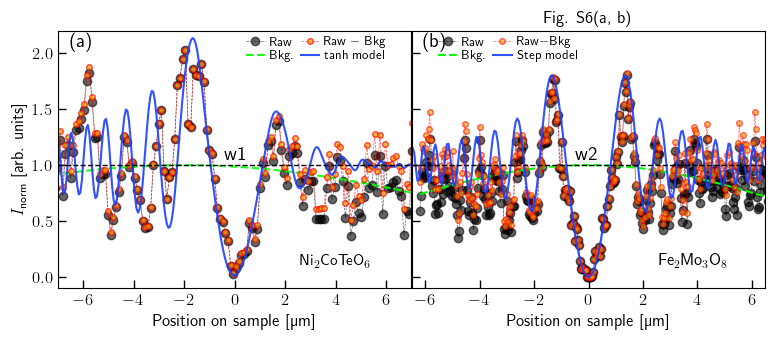

In [27]:
fig, ax = plt.subplots(1,2,figsize=(8.5,3.5))
ax[0].plot(xco, yco, 'o', color= 'black', label='Raw', markersize=6, markeredgewidth=-1, alpha=0.6, linestyle='--', lw=0.5)
ax[0].plot(xco, ygco, '--', color= 'lime', label='Bkg.',  lw=1.5, alpha=0.9)
ax[0].plot(xco, yco-ygco+1, 'o', color= 'red',  markersize=4, markerfacecolor='orange', label=r'Raw $-$ Bkg',  lw=0.5, alpha=0.7, linestyle='--')
ax[0].plot(-x_det, line_ncto_sim, '-', color='#1C3FFD', label=r'tanh model',  lw=1.5, alpha=0.9, )
ax[0].axhline(y=1, color='black', linestyle='--', lw=1, )
ax[0].set_xlim(-7, 7)
ax[0].set_ylim(-0.1, 2.2)
ax[0].legend(frameon=False, ncol=2, columnspacing=.5, bbox_to_anchor=(0.5, 1.02), markerscale=1, handlelength=1.5, handletextpad=0.4,  labelspacing=0.2,fontsize=9)
ax[0].tick_params(top=False, labeltop=False, bottom=True, labelbottom=True, direction='in')
ax[0].tick_params(axis='both', length=6, width=1, labelsize=12)
# ax[0].set_xlabel('Position on sample [µm]', fontsize=12)
ax[0].set_xlabel('Position on sample [µm]', fontsize=12)
ax[0].set_ylabel(r'$I_\text{norm}$ [arb. units]', fontsize=12)
ax[0].text(2.6, 0.1, r'Ni$_2$CoTeO$_6$', fontsize=11)
ax[0].text(-6.5, 2.05, r'(a)', fontsize=14)
ax[0].text(-0.4, 1.05, r'w1', fontsize=14)
#################################################################################
ax[1].plot(xfe, yfe, 'o', color= 'black', label='Raw', markersize=6, markeredgewidth=-1, alpha=0.6, linestyle='--', lw=0.5)
ax[1].plot(xfe, ygfe, '--', color= 'lime', label='Bkg.',  lw=1.5, alpha=1, )
ax[1].plot(xfe, yfe-ygfe+1, 'o', color= 'red',  markersize=4, markerfacecolor='orange', label=r'Raw$-$Bkg',  lw=0.5, alpha=0.6, linestyle='--')
ax[1].plot(x_det, line_fmo_sim, '-', color='#1C3FFD', label='Step model',  lw=1.5, alpha=0.9, )
ax[1].axhline(y=1, color='black', linestyle='--', lw=1, )
ax[1].set_xlim(-6.5, 6.5)
ax[1].set_ylim(-0.1, 2.2)
ax[1].legend(frameon=False, ncol=2, columnspacing=.5, bbox_to_anchor=(0.5, 1.02), markerscale=1, handlelength=1.5, handletextpad=0.4,  labelspacing=0.2,fontsize=9)
ax[1].tick_params(top=False, labeltop=False, bottom=True, labelbottom=False, direction='in')
ax[1].tick_params(left=True, labelleft=False, bottom=True, labelbottom=True, direction='in')
ax[1].tick_params(axis='both', length=6, width=1, labelsize=12)
ax[1].set_xlabel('Position on sample [µm]', fontsize=12)
#ax[1].set_ylabel(r'$I_\text{norm}$ [arb. units]', fontsize=12)
ax[1].text(2.6,0.1, f'Fe$_2$Mo$_3$O$_8$', fontsize=12)
ax[1].text(-6.1, 2.05, r'(b)', fontsize=14)
ax[1].text(-0.5, 1.05, r'w2', fontsize=14)
ax[1].set_title('Fig. S6(a, b)')
####################################################################
fig.tight_layout()
fig.subplots_adjust(left=0.15, wspace=0.001, hspace=0.03)
# plt.savefig('FigS6_NCTO_FMO_profiles_1w.png', dpi=300, format='png', metadata=None,
#         bbox_inches='tight', pad_inches=0.1,
#         facecolor='auto', edgecolor='auto',
#         backend=None)

In [28]:
#plt.close('all')